# Tox21, ToxCast and SIDER — data import and exploratory data analysis

## 1. Install dependencies


In [96]:
!pip install scikit-fingerprints pandas rdkit datamol

In [97]:
import json, hashlib, platform, urllib.request
from datetime import datetime, timezone
from importlib.metadata import version
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.precision', 3)  # Display only; saved values retain precision.
URLS = {
    'tox21': 'https://raw.githubusercontent.com/the-ahuja-lab/ChemicalDice/refs/heads/main/datasets/TDC/Toxicity/tox21.tab',
    'toxcast': 'https://raw.githubusercontent.com/the-ahuja-lab/ChemicalDice/refs/heads/main/datasets/TDC/Toxicity/toxcast.tab',
}


In [98]:
from pathlib import Path

RAW = Path('data_raw')
OUT = Path('data_processed')
RAW.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
print(f"Raw data will be stored in: {RAW}")
print(f"Processed data will be stored in: {OUT}")

Raw data will be stored in: data_raw
Processed data will be stored in: data_processed


## 2. Import datasets

In [99]:
raw_tables = {}
for name, url in URLS.items():
    raw_tables[name] = pd.read_csv(url, sep='\t')
    assert {'X', 'ID'}.issubset(raw_tables[name].columns), f'Unexpected {name} schema'
    print(name, 'rows:', len(raw_tables[name]), 'targets:', len(raw_tables[name].columns) - 2)
df_tox21 = raw_tables['tox21']
df_toxcast = raw_tables['toxcast']
#Renaming column and Changing column datatype
df_tox21.rename(columns={"X": "SMILES"},inplace=True)
df_toxcast.rename(columns={"X": "SMILES"},inplace=True)
display(df_tox21.head(3))
display(df_toxcast.head(3))
print(f"Tox21 Shape ={df_tox21.shape}")
print(f"ToxCast Shape = {df_toxcast.shape}")
#Are there any duplicate values?
if len(df_tox21.SMILES.unique()) == df_tox21.shape[0]:
  print("No Duplicate Values in Tox21")
else:
    print(f"There are {df_tox21.shape[0]-df_tox21.SMILES.unique()} Duplicate Values in Tox21")
if len(df_toxcast.SMILES.unique()) == df_toxcast.shape[0]:
  print("No Duplicate Values in ToxCast")
else:
    print(f"There are {df_toxcast.shape[0]-df_toxcast.SMILES.unique()} Duplicate Values in ToxCast")
#We can also look at datatype for each of the columns
print("Tox21 columns")
display(df_tox21.dtypes)
print("Toxcast columns")
display(df_toxcast.dtypes)
print("Tox21 summary statistics")
df_tox21_stats=df_tox21.describe()
display(df_tox21_stats)
print("Toxcast summary statistics")
df_toxcast_stats=df_toxcast.describe()
display(df_toxcast_stats)


tox21 rows: 7831 targets: 12
toxcast rows: 8576 targets: 617


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,ID,SMILES
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C


,SMILES,ACEA_T47D_80hr_Negative,ACEA_T47D_80hr_Positive,APR_HepG2_CellCycleArrest_24h_dn,APR_HepG2_CellCycleArrest_24h_up,APR_HepG2_CellCycleArrest_72h_dn,APR_HepG2_CellLoss_24h_dn,APR_HepG2_CellLoss_72h_dn,APR_HepG2_MicrotubuleCSK_24h_dn,APR_HepG2_MicrotubuleCSK_24h_up,...,Tanguay_ZF_120hpf_PE_up,Tanguay_ZF_120hpf_PFIN_up,Tanguay_ZF_120hpf_PIG_up,Tanguay_ZF_120hpf_SNOU_up,Tanguay_ZF_120hpf_SOMI_up,Tanguay_ZF_120hpf_SWIM_up,Tanguay_ZF_120hpf_TRUN_up,Tanguay_ZF_120hpf_TR_up,Tanguay_ZF_120hpf_YSE_up,ID
0,O=[N+]([O-])c1ccc(Cl)cc1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Drug 0
1,C[SiH](C)O[Si](C)(C)O[Si](C)(C)O[SiH](C)C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Drug 1
2,CN1CCN(C(=O)C2CCCCC2)CC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Drug 2


Tox21 Shape =(7831, 14)
ToxCast Shape = (8576, 619)
No Duplicate Values in Tox21
No Duplicate Values in ToxCast
Tox21 columns


,0
NR-AR,float64
NR-AR-LBD,float64
NR-AhR,float64
NR-Aromatase,float64
NR-ER,float64
NR-ER-LBD,float64
NR-PPAR-gamma,float64
SR-ARE,float64
SR-ATAD5,float64
SR-HSE,float64


...

,0
SMILES,object
ACEA_T47D_80hr_Negative,float64
ACEA_T47D_80hr_Positive,float64
APR_HepG2_CellCycleArrest_24h_dn,float64
APR_HepG2_CellCycleArrest_24h_up,float64
...,...
Tanguay_ZF_120hpf_SWIM_up,float64
Tanguay_ZF_120hpf_TRUN_up,float64
Tanguay_ZF_120hpf_TR_up,float64
Tanguay_ZF_120hpf_YSE_up,float64


Tox21 summary statistics


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,7265.000,6758.000,6549.000,5821.000,6193.000,6955.000,6450.000,5832.000,7072.000,6467.000,5810.000,6774.000
mean,0.043,0.035,0.117,0.052,0.128,0.050,0.029,0.162,0.037,0.058,0.158,0.062
std,0.202,0.184,0.322,0.221,0.334,0.219,0.167,0.368,0.190,0.233,0.365,0.242
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Toxcast summary statistics


,ACEA_T47D_80hr_Negative,ACEA_T47D_80hr_Positive,APR_HepG2_CellCycleArrest_24h_dn,APR_HepG2_CellCycleArrest_24h_up,APR_HepG2_CellCycleArrest_72h_dn,APR_HepG2_CellLoss_24h_dn,APR_HepG2_CellLoss_72h_dn,APR_HepG2_MicrotubuleCSK_24h_dn,APR_HepG2_MicrotubuleCSK_24h_up,APR_HepG2_MicrotubuleCSK_72h_dn,...,Tanguay_ZF_120hpf_OTIC_up,Tanguay_ZF_120hpf_PE_up,Tanguay_ZF_120hpf_PFIN_up,Tanguay_ZF_120hpf_PIG_up,Tanguay_ZF_120hpf_SNOU_up,Tanguay_ZF_120hpf_SOMI_up,Tanguay_ZF_120hpf_SWIM_up,Tanguay_ZF_120hpf_TRUN_up,Tanguay_ZF_120hpf_TR_up,Tanguay_ZF_120hpf_YSE_up
count,1731.000,1731.000,1034.000,1034.000,1034.000,1034.000,1034.000,1034.000,1034.000,1019.000,...,1021.000,1021.000,1021.000,1021.000,1021.000,1021.000,1021.000,1021.000,1021.000,1021.000
mean,0.256,0.172,0.169,0.042,0.235,0.290,0.430,0.060,0.088,0.063,...,0.043,0.119,0.056,0.046,0.109,0.039,0.034,0.058,0.081,0.126
std,0.437,0.377,0.375,0.200,0.424,0.454,0.495,0.238,0.283,0.243,...,0.203,0.323,0.230,0.210,0.311,0.194,0.182,0.233,0.273,0.332
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [100]:
from skfp.datasets.moleculenet import load_sider

# Directly load SIDER data. The 'data_dir' argument handles internal caching for load_sider.
#raw_tables['sider'] = load_sider(data_dir=str(RAW / 'sider_cache'), as_frame=True)

df_SIDER = load_sider(as_frame=True)
#Renaming column and Changing column datatype
df_SIDER.rename(columns={"X": "SMILES"},inplace=True)
display(df_SIDER.head(3))
print(f"SIDER Shape ={df_SIDER.shape}")
#Are there any duplicate values?
if len(df_SIDER.SMILES.unique()) == df_SIDER.shape[0]:
  print("No Duplicate Values in SIDER")
else:
    print(f"There are {df_SIDER.shape[0]-df_SIDER.SMILES.unique()} Duplicate Values in Tox21")
#We can also look at datatype for each of the columns
print("SIDER columns")
display(df_SIDER.dtypes)
print("SIDER summary statistics")
df_SIDER_stats=df_SIDER.describe()
display(df_SIDER_stats)

,SMILES,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,...,"Congenital, familial and genetic disorders",Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications"
0,C(CNCCNCCNCCN)N,1,1,0,0,1,1,1,0,0,...,0,0,1,1,0,0,1,1,1,0
1,CC(C)(C)C1=CC(=C(C=C1NC(=O)C2=CNC3=CC=CC=C3C2=O)O)C(C)(C)C,0,1,0,0,1,1,1,0,0,...,0,1,1,0,0,0,1,0,1,0
2,CC[C@]12CC(=C)[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)O)CCC4=CCCC[C@H]34,0,1,0,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0


SIDER Shape =(1427, 28)
No Duplicate Values in SIDER
SIDER columns


,0
SMILES,object
Hepatobiliary disorders,int64
Metabolism and nutrition disorders,int64
Product issues,int64
Eye disorders,int64
Investigations,int64
Musculoskeletal and connective tissue disorders,int64
Gastrointestinal disorders,int64
Social circumstances,int64
Immune system disorders,int64


SIDER summary statistics


,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,Reproductive system and breast disorders,...,"Congenital, familial and genetic disorders",Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications"
count,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,...,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000,1427.000
mean,0.521,0.698,0.015,0.614,0.807,0.699,0.910,0.176,0.718,0.509,...,0.177,0.705,0.743,0.712,0.638,0.088,0.462,0.692,0.914,0.663
std,0.500,0.459,0.123,0.487,0.395,0.459,0.287,0.381,0.450,0.500,...,0.382,0.456,0.437,0.453,0.481,0.283,0.499,0.462,0.281,0.473
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
50%,1.000,1.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,...,0.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000
75%,1.000,1.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,...,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 3. Exploratory Data Visualization

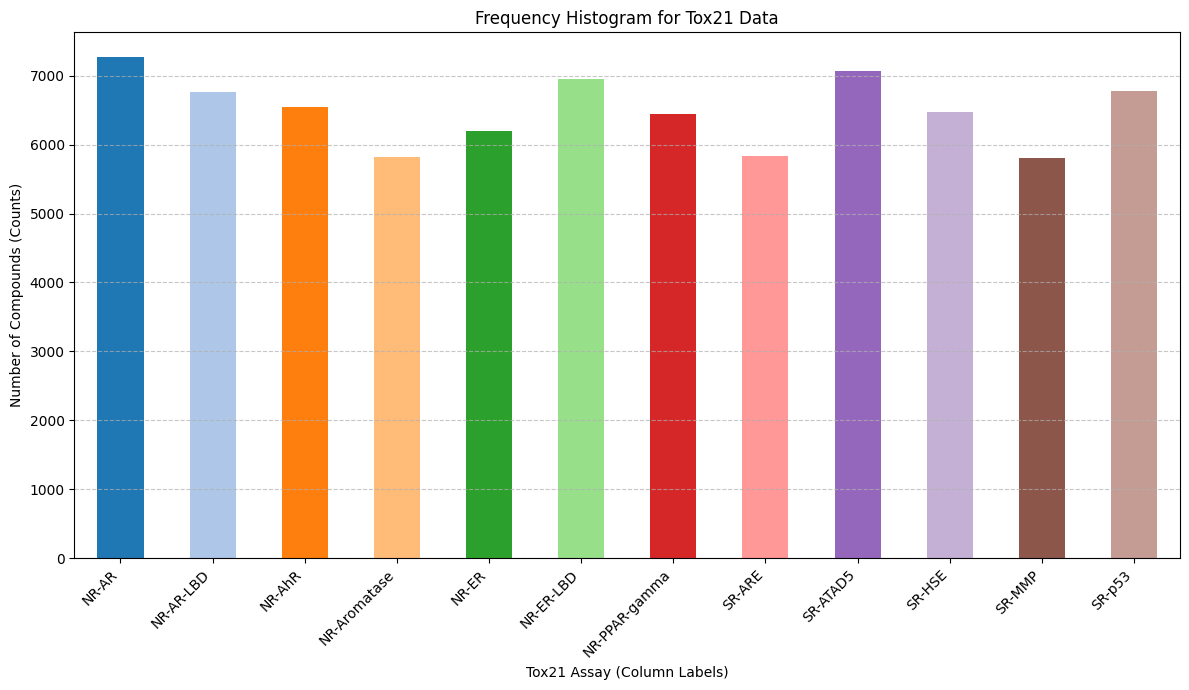

In [101]:
df_tox21_counts = df_tox21_stats.loc["count","NR-AR":"SR-p53"]

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create a bar chart directly from the Series
plt.figure(figsize=(12, 7))

# Get a default colormap and generate colors for each bar
colors = cm.tab20(range(len(df_tox21_counts))) # tab20 is a good categorical colormap

df_tox21_counts.plot.bar(color=colors)

# Add title and labels
plt.title('Frequency Histogram for Tox21 Data')
plt.xlabel('Tox21 Assay (Column Labels)')
plt.ylabel('Number of Compounds (Counts)')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


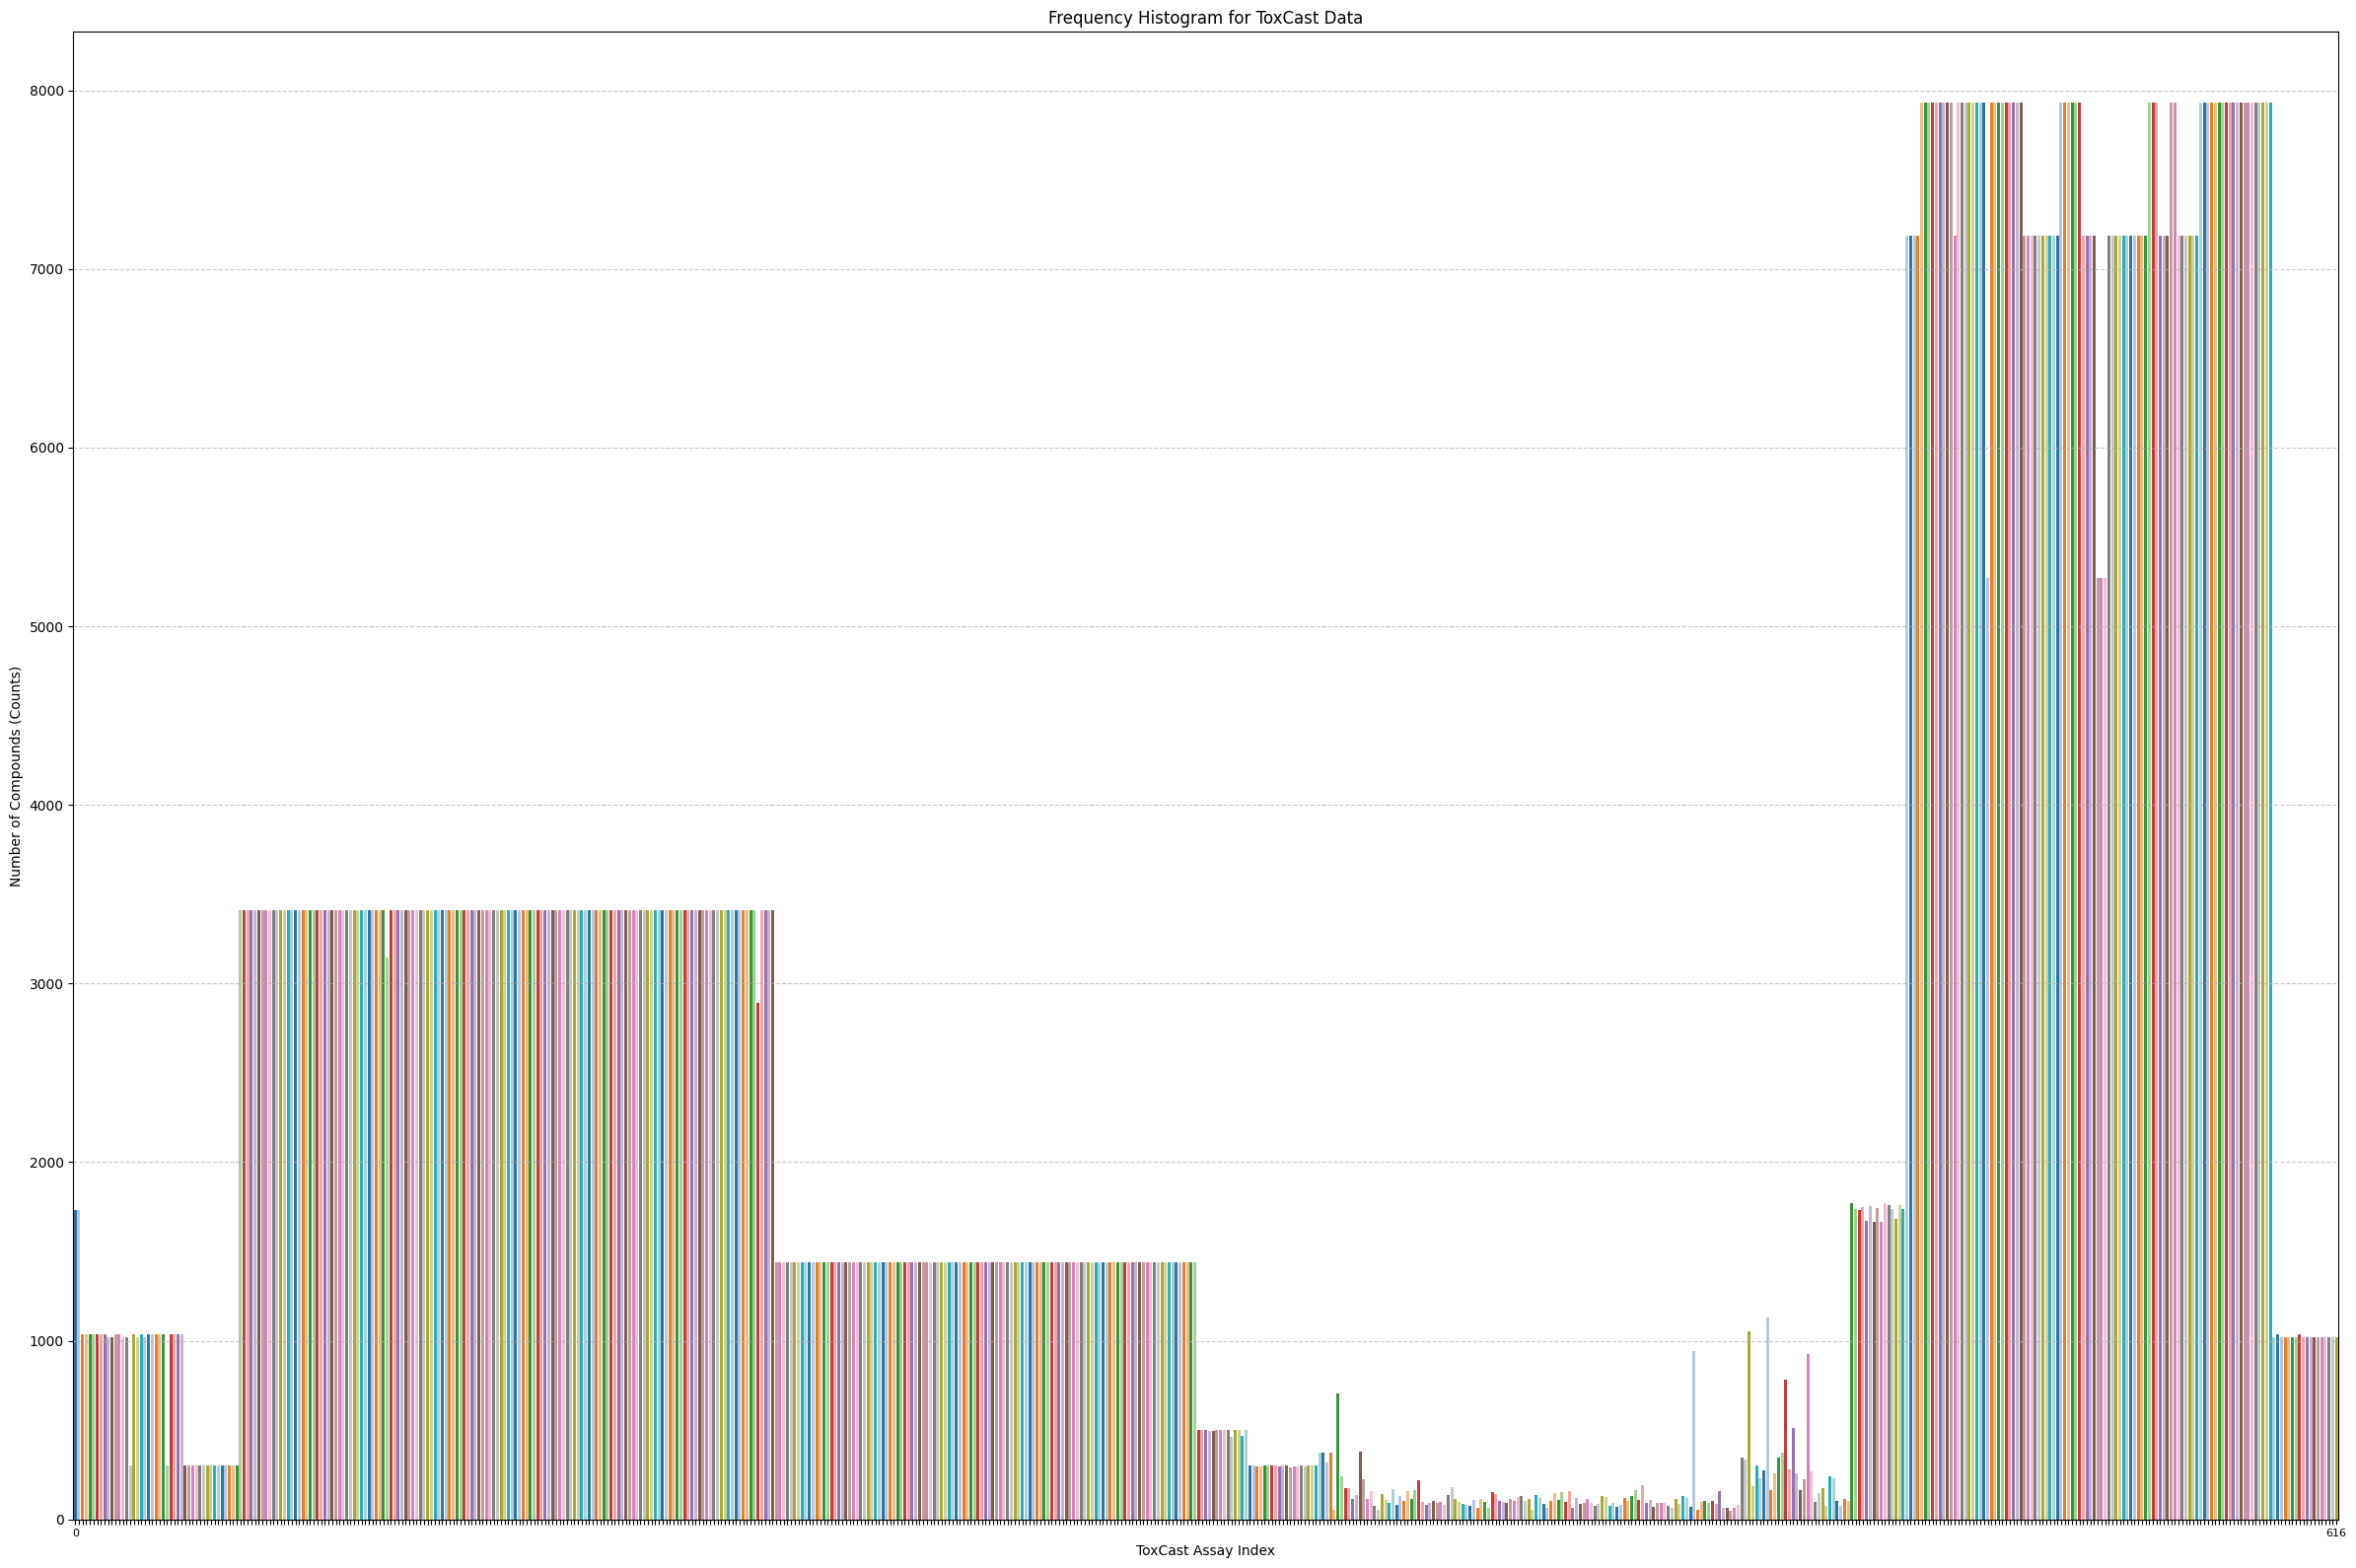

Imbalanced Dataset


In [124]:
df_toxcast_counts = df_toxcast_stats.loc["count","ACEA_T47D_80hr_Negative":"Tanguay_ZF_120hpf_YSE_up"]
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Create a bar chart using Seaborn
plt.figure(figsize=(24, 16)) # Increased figure size for better readability
sns.barplot(x=list(range(len(df_toxcast_counts))), y=df_toxcast_counts.values, hue=df_toxcast_counts.index, palette="tab20", legend=False)

# Add title and labels
plt.title('Frequency Histogram for ToxCast Data')
plt.xlabel('ToxCast Assay Index')
plt.ylabel('Number of Compounds (Counts)')

# Only display the first and last x-axis labels
tick_positions = list(range(len(df_toxcast_counts)))
tick_labels = [''] * len(df_toxcast_counts)
if len(tick_positions) > 0:
    tick_labels[0] = str(tick_positions[0])
if len(tick_positions) > 1:
    tick_labels[-1] = str(tick_positions[-1])
plt.xticks(tick_positions, tick_labels, rotation=0, ha='center', fontsize=8) # No rotation needed for just two labels

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Imbalanced Dataset")

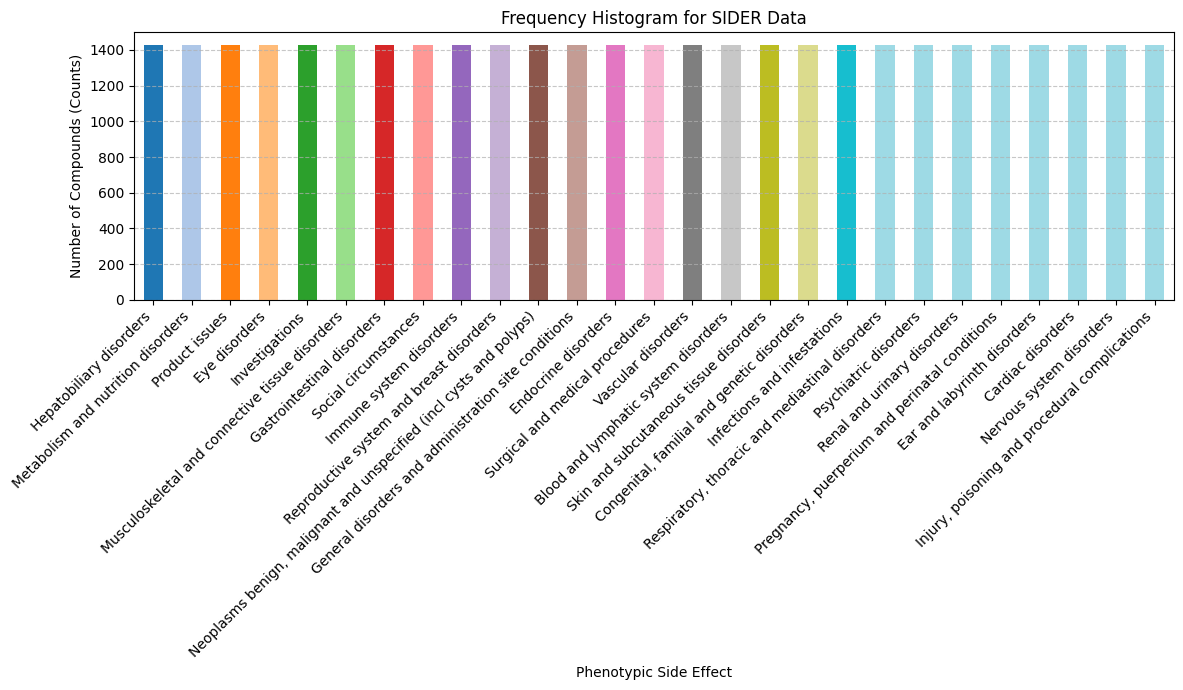

Balanced Dataset


In [114]:
df_SIDER_counts = df_SIDER_stats.loc["count","Hepatobiliary disorders":"Injury, poisoning and procedural complications"]
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create a bar chart directly from the Series
plt.figure(figsize=(12, 7))

# Get a default colormap and generate colors for each bar
colors = cm.tab20(range(len(df_SIDER_counts))) # tab20 is a good categorical colormap

df_SIDER_counts.plot.bar(color=colors)

# Add title and labels
plt.title('Frequency Histogram for SIDER Data')
plt.xlabel('Phenotypic Side Effect')
plt.ylabel('Number of Compounds (Counts)')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Balanced Dataset")

##What can these datasets actually tell us?






# SIDER(Phenotypic Side effects)

## **Data provenance & collection method**.
SIDER was built by text-mining drug labels and package inserts using natural language processing (NLP). The 2010 version used COSTART/UMLS synonyms and section detection to extract drug–side-effect pairs; SIDER 4 expanded to MedDRA terms, added dependency-rule NLP to distinguish adverse reactions from negations, speculation, and pre-existing disease, and used extracted indications to reduce false positives. Frequency information (patient percentages) is available for only about one-third of drug–side-effect pairs, and placebo-comparison frequencies exist for just a subset of those. Data is not from randomized clinical trials and placebo comparison data is only available for a subset of drugs.
## **Key statistical / modeling assumptions.**

Synonym and section mapping correctly recovers intended drug–effect pairs. Excluding indication terms reduces errors but may also remove an outcome that is both an indication and an adverse effect.

Frequency-table heuristics correctly distinguish drug, placebo, and other percentages from label tables.

ATC-class enrichment and anatomical associations (Fisher tests, randomization) assume drug records are sufficiently comparable; shared effects are interpreted as possible shared mechanisms.

## **Critical Limitations vs Gold Standard Trials**
It says on the website that SIDER is static and outdated(2015)

Data is only collected from Patient Adverse Reaction Data for drugs that passed clinical trials and reached the market. Therefore randomized placebo controlled clinical trials haven't been performed to scientifically observe these side effects which can lead to sampling biases like time and selection bias.

Post-market associations show a different reporting trend than clinical-trial associations: prediction performance drops dramatically when moving from clinical-trial side effects (AUROC ~0.944) to post-marketing sets (AUROC ~0.728 for SIDER, ~0.618 for OFFSIDES[M10]. Building a model for SIDER data is therefore harder!

Adverse Drug Events may occur if the drug is consumed above the "No Observed Adverse Effect Level" which gets mixed in the SIDER data with the genuine Adverse Drug Events.

Workflow signal: Treat SIDER as a hypothesis-generating label source, not a causal ground truth.



###Tox21(Nuclear and Stress Response Pathway Receptors) and ToxCast(Experimental Assays)

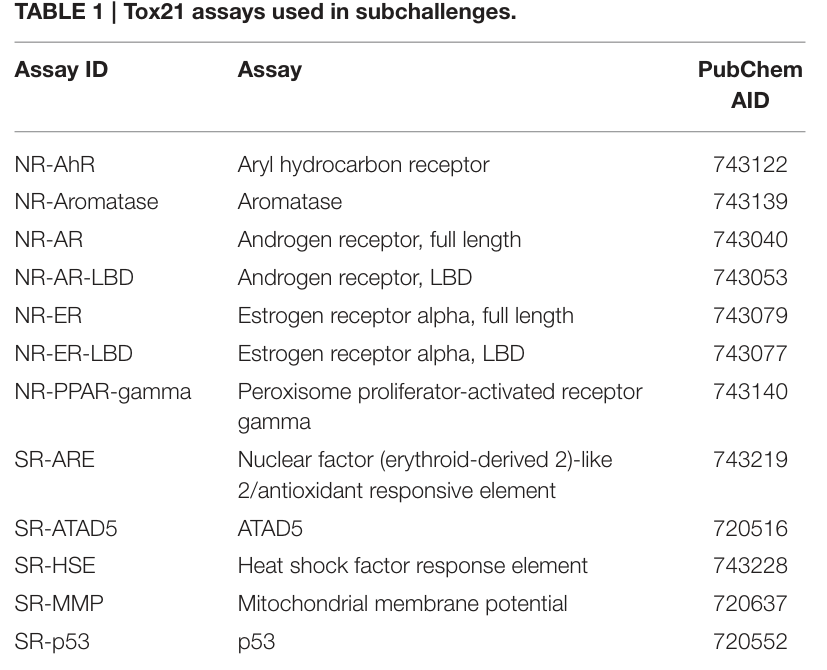

Detailed list of assay sources(by company) for Toxcast can be found here https://gaftp.epa.gov/COMPTOX/High_Throughput_Screening_Data/Previous_Data/ToxcastdatareleaseSept2018/assay_description/Documentation_2018-10-24.pdf#1135#824

# **Tox21 / ToxCast (In Vitro High Throughput Screening)**
## **Data provenance & collection method**
 ToxCast/Tox21 generated in vitro high-throughput screening (HTS) data for thousands of chemicals across hundreds of assay endpoints. The chemical library was selected using practical constraints: commercial availability, DMSO solubility, stability, and suitability for automated systems (low volatility, moderate LogP). About 92% of procured candidates were DMSO-soluble and entered testing; volatile or insoluble chemicals are systematically excluded. The Tox21 10K library covers 12 pathway endpoints (7 nuclear receptor assays, 5 stress-response assays). The 12 assays and their PubChem AIDs are listed in the above Table.
 ## **Statistical / modeling methodology**
 Each chemical concentration series is fitted to three predictive models: a constant function (no activity), a 4-parameter Hill function, and a gain–loss function (two sequential Hill functions).

 The winning model is selected by lowest AIC (Akaike Information Criterion)

AC50 (concentration at 50% of maximum activity), Hill slope, and maximum activity are derived for active chemicals

Biological relevance is determined by: response above a signal noise band (e.g., >5× baseline median absolute deviation), modeled top above a response cutoff, and lower AIC than the constant model

 ## **Assumptions**

 Biological concentration dosage data can be summarized using binary thresholds(active/inactive).

 A reporter/sensor change reflects pathway-specific perturbation, not readout interference, generalized cell injury, or confounded by another pathway.

 ## **Limitations**

 Channel interference in ratiometric β-lactamase assays can confound activity calls for up to 85% of active chemicals in the data.

 Missing Data is a sign of inconclusive lab outcomes so imputation will not work!

 A 2024 analysis[M11] found predictive value of ToxCast data for traditional in vivo endpoints was poor (r ≤ 0.3) in comparison to High Throughput Toxicokinetics(HTTK) Data.


### References

- **[S1]** Kuhn M, Campillos M, Letunic I, Jensen LJ, Bork P. *A side effect resource to capture phenotypic effects of drugs.* Molecular Systems Biology. 2010;6:343. doi: **10.1038/msb.2009.98**. Uploaded `02-A-side-effect-resource-to-capture-phenotypic-effects-of-drugs.pdf`; collection/methods pp. 1, 5–6; association and frequency analyses pp. 2–5.
- **[S4]** Kuhn M, Letunic I, Jensen LJ, Bork P. *The SIDER database of drugs and side effects.* Nucleic Acids Research. **2016;44(D1):D1075–D1079**, online 19 October 2015. doi: **10.1093/nar/gkv1075**. Uploaded `01-SIDER-Database-of-drugs-and-side-effects.pdf`; extraction/filtering pp. 2–3; validation pp. 3–4; content Table 1, p. 3.
- **[TC]** Richard AM et al. *ToxCast Chemical Landscape: Paving the Road to 21st Century Toxicology.* Chemical Research in Toxicology. 2016;29:1225–1251. doi: **10.1021/acs.chemrestox.6b00135**. Uploaded `03-ToxCast.pdf`; selection pp. 3–6; QC pp. 7–8; coverage methods pp. 9–11 and §§3.3–3.4; conclusions p. 23. This review uses the perspective's methods and limitations; it does not claim to reproduce its chemical-space calculations.
- **[OV]** Huang R et al. *Tox21Challenge to Build Predictive Models of Nuclear Receptor and Stress Response Pathways as Mediated by Exposure to Environmental Chemicals and Drugs.* Frontiers in Environmental Science. 2016;3:85. doi: **10.3389/fenvs.2015.00085**. Uploaded `04-Tox21-supplementary.pdf`; assay list p. 2; collection pp. 3–4; evaluation/consensus pp. 4–7.
- **[BOOK]** Huang R, Xia M, editors. *Tox21 Challenge to Build Predictive Models of Nuclear Receptor and Stress Response Pathways As Mediated by Exposure to Environmental Toxicants and Drugs.* Frontiers Media, 2017. doi: **10.3389/978-2-88945-197-5**. Uploaded `05-Tox21.PDF`. Chapter methods and relevant results were reviewed; the volume's separately linked supplementary files were not supplied or assumed to have been read.
- **[M1]** Mayr A et al. *DeepTox: Toxicity Prediction using Deep Learning.* 2016;3:80. doi: **10.3389/fenvs.2015.00080**. BOOK PDF pp. 18–32.
- **[M2]** Abdelaziz A et al. *Consensus Modeling for HTS Assays Using In silico Descriptors Calculates the Best Balanced Accuracy in Tox21 Challenge.* 2016;4:2. doi: **10.3389/fenvs.2016.00002**. BOOK PDF pp. 33–44.
- **[M3]** Barta G. *Identifying Biological Pathway Interrupting Toxins Using Multi-Tree Ensembles.* 2016;4:52. doi: **10.3389/fenvs.2016.00052**. BOOK PDF pp. 45–56.
- **[M4]** Uesawa Y. *Rigorous Selection of Random Forest Models for Identifying Compounds that Activate Toxicity-Related Pathways.* 2016;4:9. doi: **10.3389/fenvs.2016.00009**. BOOK PDF pp. 57–62.
- **[M5]** Drwal MN et al. *Molecular similarity-based predictions of the Tox21 screening outcome.* 2015;3:54. doi: **10.3389/fenvs.2015.00054**. BOOK PDF pp. 63–71.
- **[M6]** Capuzzi SJ et al. *QSAR Modeling of Tox21 Challenge Stress Response and Nuclear Receptor Signaling Toxicity Assays.* 2016;4:3. doi: **10.3389/fenvs.2016.00003**. BOOK PDF pp. 72–78.
- **[M7]** Stefaniak F. *Prediction of Compounds Activity in Nuclear Receptor Signaling and Stress Pathway Assays Using Machine Learning Algorithms and Low-Dimensional Molecular Descriptors.* 2015;3:77. doi: **10.3389/fenvs.2015.00077**. BOOK PDF pp. 79–85.
- **[M8]** Koutsoukas A et al. *Predictive Toxicology: Modeling Chemical Induced Toxicological Response Combining Circular Fingerprints with Random Forest and Support Vector Machine.* 2016;4:11. doi: **10.3389/fenvs.2016.00011**. BOOK PDF pp. 86–94.
- **[M9]** Ribay K et al. *Predictive Modeling of Estrogen Receptor Binding Agents Using Advanced Cheminformatics Tools and Massive Public Data.* 2016;4:12. doi: **10.3389/fenvs.2016.00012**. BOOK PDF pp. 95–104. M1–M9 are all in *Frontiers in Environmental Science*.

- **[M10]** Galeano, D. and Paccanaro, A., 2022. Machine learning prediction of side effects for drugs in clinical trials. Cell reports methods, 2(12).

- **[M11]** Rodea-Palomares, Ismael, and Audrey J. Bone. "Predictive value of the ToxCast/Tox21 high throughput toxicity screening data for approximating in vivo ecotoxicity endpoints and ecotoxicological risk in eco-surveillance applications." Science of the Total Environment 914 (2024): 169783.